#### Experiment 1

#### In this experiment we are dropping CN and replacing it with BltPct

In [1]:
# This cell imports the tools needed for analysis.
# NumPy handles numeric data, Pandas handles tables, and GeoPandas works with spatial datasets such as shapefiles.
# Matplotlib and Seaborn are used to make plots and charts.
# scikit-learn contains the machine learning model and evaluation tools.
# Please bear in mind that these comments are a combination of my own knowledge + what was already in the notebook.

## Importing the necessary packages. 
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import geopandas as gpd 
import sklearn
import matplotlib.pyplot as plt
import shap # used for model explainability and feature importance.
import pickle # Pickle allows Python objects to be saved to disk and reused later.
import geocube # geocube is used to convert vector data into a raster grid for mapping.
import traceback #  a standard Python module for showing detailed error stacks.

from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, classification_report, cohen_kappa_score, confusion_matrix

c:\Users\Sandhra George\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# This cell loads the shapefile that contains the flood sample locations.
# A shapefile is a spatial GIS (Geographic Information System) file with geometry and attribute data.
# The dataset contains flood sample points and their conditioning features.
# We display the first rows to confirm the data was read correctly.

# Read the shapefile.
# The shapefile includes 302 locations and were obtained from the flood inventory and data collections (coordinates of flood hit-locations).
# Flooded = 0 indicates non-flooded location while Flooded = 1 indicates flooded location. Label will be used as the target variable for the machine learning model as we are trying to predict the probability of flooding at a given location.
# Every location has values for the 10 flood conditioning features.
df = gpd.read_file(r"C:\Users\Sandhra George\FSM-data\QGIS_Data\Sample_points\Nyabarongo_SamplePoints_Final.shp")
df.head()

,fid,x,y,Label,Aspect,CN,Curvature,DEM,DTRiver,DTRoad,NDVI,Slope,TWI,Rainfall,OBJECTID,NDVI_Chang,BuiltPct,WetnessDec,geometry
0,1.0,490699.0,4790799.0,1.0,103.5480,80,9.556440e+09,1576.0,240.1400,379.6950,0.595304,35.39290,-7.691620,141.0,100298.0,-0.001144,0.00,0.0,POINT (490699 4790799)
1,2.0,494619.0,4790376.0,1.0,1.7357,77,2.730410e+09,1372.0,0.0000,42.4512,0.397266,7.82190,-4.825820,138.0,99172.0,-0.028670,6.75,0.0,POINT (494619 4790376)
2,3.0,472067.0,4806436.0,1.0,315.0000,77,-5.460830e+09,1378.0,42.4512,361.4590,0.250189,1.34835,0.772496,128.6,146362.0,0.285411,0.00,30.0,POINT (472067 4806436)
3,4.0,467827.0,4806267.0,1.0,232.1250,80,-2.730410e+09,1393.0,84.9023,123.7650,0.397909,2.71616,2.248400,128.6,145801.0,-0.165951,7.25,0.0,POINT (467827 4806267)
4,5.0,458251.0,4814882.0,1.0,80.5377,80,0.000000e+00,1480.0,30.0175,90.0525,0.178881,5.78086,-4.048840,126.0,167065.0,-0.016271,0.00,9.0,POINT (458251 4814882)


In [3]:
# Drop the original CN feature and other excluded columns from the feature dataset.
df = df.drop(columns=['CN', 'NDVI_Chang', 'WetnessDec', 'OBJECTID', 'fid'], errors='ignore')

assert 'CN' not in df.columns
assert 'BuiltPct' in df.columns

df.head()

,x,y,Label,Aspect,Curvature,DEM,DTRiver,DTRoad,NDVI,Slope,TWI,Rainfall,BuiltPct,geometry
0,490699.0,4790799.0,1.0,103.5480,9.556440e+09,1576.0,240.1400,379.6950,0.595304,35.39290,-7.691620,141.0,0.00,POINT (490699 4790799)
1,494619.0,4790376.0,1.0,1.7357,2.730410e+09,1372.0,0.0000,42.4512,0.397266,7.82190,-4.825820,138.0,6.75,POINT (494619 4790376)
2,472067.0,4806436.0,1.0,315.0000,-5.460830e+09,1378.0,42.4512,361.4590,0.250189,1.34835,0.772496,128.6,0.00,POINT (472067 4806436)
3,467827.0,4806267.0,1.0,232.1250,-2.730410e+09,1393.0,84.9023,123.7650,0.397909,2.71616,2.248400,128.6,7.25,POINT (467827 4806267)
4,458251.0,4814882.0,1.0,80.5377,0.000000e+00,1480.0,30.0175,90.0525,0.178881,5.78086,-4.048840,126.0,0.00,POINT (458251 4814882)


In [4]:
# This cell prints a summary of the dataset.
# It helps us understand the range, average, and spread of each variable.

print(df.describe().T)

           count          mean           std           min           25%  \
x          302.0  4.711318e+05  1.864861e+04  4.361400e+05  4.583772e+05   
y          302.0  4.799599e+06  2.799172e+04  4.719460e+06  4.783525e+06   
Label      302.0  5.000000e-01  5.008299e-01  0.000000e+00  0.000000e+00   
Aspect     302.0  1.613450e+02  1.075523e+02 -1.000000e+00  6.882823e+01   
Curvature  302.0  4.204126e+08  7.948143e+09 -4.368660e+10 -2.730410e+09   
DEM        302.0  1.761007e+03  2.652039e+02  1.349000e+03  1.595250e+03   
DTRiver    302.0  3.664178e+02  6.856775e+02  0.000000e+00  3.001750e+01   
DTRoad     302.0  1.791291e+02  2.338144e+02  0.000000e+00  3.001750e+01   
NDVI       302.0  5.469774e-01  1.199703e-01  9.711860e-02  4.854877e-01   
Slope      302.0  1.056722e+01  8.086491e+00  0.000000e+00  4.077317e+00   
TWI        302.0 -3.815989e+00  3.930059e+00 -8.049660e+00 -6.042820e+00   
Rainfall   302.0  1.328503e+02  7.341330e+00  1.153000e+02  1.269000e+02   
BuiltPct   3

In [5]:
# This cell checks for missing values.
# Missing values can affect model performance, so we need to know whether cleaning is needed.

## Check if there is null values
print(df.isnull().sum())
#df = df.dropna()

x            0
y            0
Label        0
Aspect       0
Curvature    0
DEM          0
DTRiver      0
DTRoad       0
NDVI         0
Slope        0
TWI          0
Rainfall     0
BuiltPct     0
geometry     0
dtype: int64


In [6]:
# This cell renames the target column from 'Flooded' to 'Label'. ( I think the 'Label' column was originally named 'Flooded' in the shapefile.)
# This makes the target variable easier to understand in the model.
# It also shows the data types to confirm the columns are correct.

df = df.rename(columns={'Flooded':'Label'})
print(df.dtypes)

x             float64
y             float64
Label         float64
Aspect        float64
Curvature     float64
DEM           float64
DTRiver       float64
DTRoad        float64
NDVI          float64
Slope         float64
TWI           float64
Rainfall      float64
BuiltPct      float64
geometry     geometry
dtype: object


<Axes: xlabel='Label', ylabel='count'>

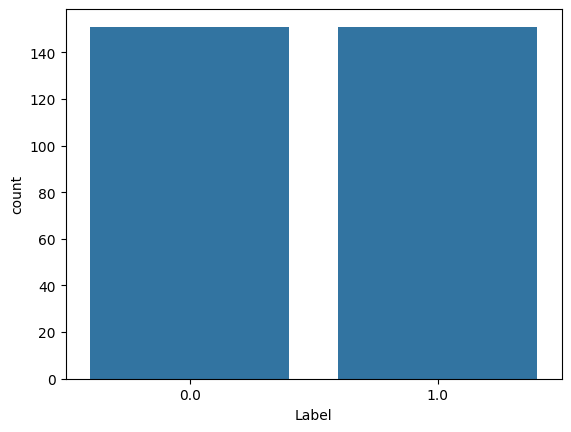

In [7]:
# This cell shows how many sample points are flooded and how many are not.
# This helps check whether the dataset is balanced.

# Therefore, here we are trying to understand the data.
# We can see from the graph that the dataset includes the same number of flooded and not flooded locations.
sns.countplot(x="Label", data=df) # 0 - Not Flooded,    1 - Flooded

In [8]:
# This cell separates the non-flooded and flooded rows into two groups.
# We remove the geometry and label columns so we can compare only the feature values between the two groups. Feature values are the input variables that will be used to predict flooding.

zero_labels = df.loc[df['Label'] == 0].drop(columns=['geometry', 'Label','x','y'])
ones_labels = df.loc[df['Label'] == 1].drop(columns=['geometry', 'Label','x','y'])

In [9]:
# This cell displays the non-flooded subset of the data.

zero_labels

,Aspect,Curvature,DEM,DTRiver,DTRoad,NDVI,Slope,TWI,Rainfall,BuiltPct
151,120.0690,2.730410e+09,1472.0,488.649,30.0175,0.319614,5.21950,-4.99628,134.5,100.00
152,61.3895,-2.730410e+09,1541.0,499.591,153.0600,0.218264,5.95281,-3.23135,142.2,70.00
153,24.3411,2.730410e+09,1730.0,437.061,123.7650,0.531311,20.98760,-7.25658,141.1,0.25
154,351.2540,9.556440e+09,1783.0,361.459,123.7650,0.517415,6.24650,-6.82730,141.1,24.75
155,206.5650,-1.365210e+09,1643.0,630.367,271.8200,0.501634,29.97850,-5.88159,136.9,0.00
...,...,...,...,...,...,...,...,...,...,...
297,180.0000,1.365210e+09,1462.0,702.692,0.0000,0.403091,5.23025,-5.16644,134.5,98.75
298,143.9730,1.365210e+09,1433.0,421.316,0.0000,0.275327,6.45774,-4.93739,139.8,100.00
299,140.9470,2.730410e+09,1504.0,618.827,120.0700,0.600530,15.85340,-4.68671,140.0,97.75
300,153.4350,0.000000e+00,1516.0,752.835,42.4512,0.588753,4.25680,-2.72646,138.6,76.00


In [10]:
# This cell displays the flooded subset of the data.
# Comparing both groups helps us understand how flood conditions differ.

ones_labels

,Aspect,Curvature,DEM,DTRiver,DTRoad,NDVI,Slope,TWI,Rainfall,BuiltPct
0,103.5480,9.556440e+09,1576.0,240.1400,379.6950,0.595304,35.39290,-7.691620,141.0,0.00
1,1.7357,2.730410e+09,1372.0,0.0000,42.4512,0.397266,7.82190,-4.825820,138.0,6.75
2,315.0000,-5.460830e+09,1378.0,42.4512,361.4590,0.250189,1.34835,0.772496,128.6,0.00
3,232.1250,-2.730410e+09,1393.0,84.9023,123.7650,0.397909,2.71616,2.248400,128.6,7.25
4,80.5377,0.000000e+00,1480.0,30.0175,90.0525,0.178881,5.78086,-4.048840,126.0,0.00
...,...,...,...,...,...,...,...,...,...,...
146,243.4350,-8.191240e+09,1888.0,30.0175,30.0175,0.700884,1.06604,-3.425820,124.2,98.00
147,270.0000,4.095620e+09,1595.0,0.0000,30.0175,0.458204,2.85844,-4.717820,135.0,48.25
148,128.2900,1.365210e+09,1428.0,150.0870,84.9023,0.641133,5.75169,-5.381830,125.9,15.50
149,196.9280,0.000000e+00,1537.0,30.0175,254.7070,0.584013,5.71255,-2.994960,126.9,0.00


<Axes: >

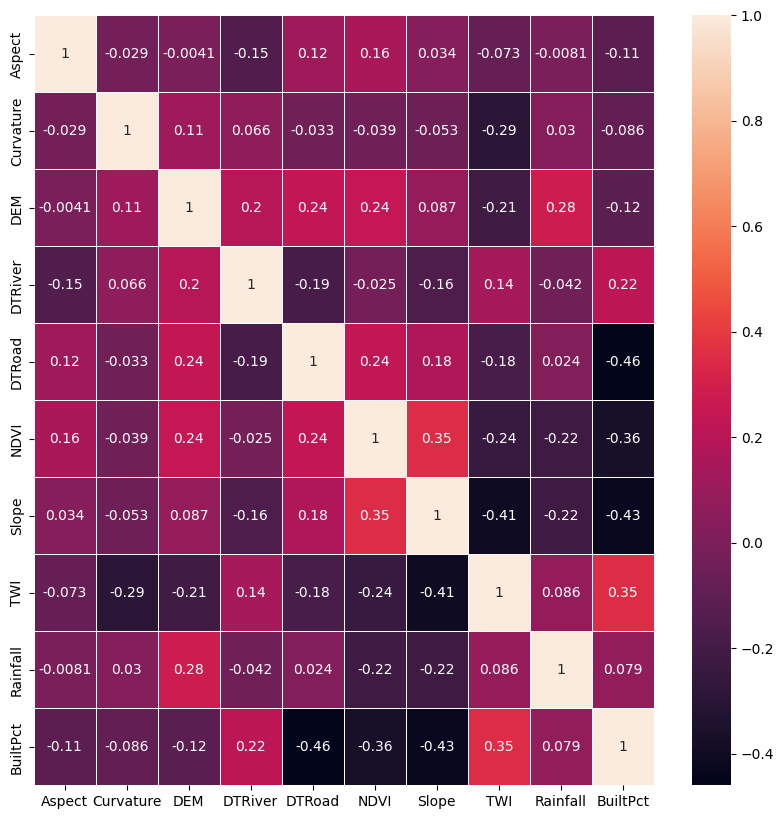

In [11]:
# This cell creates a correlation heatmap for non-flooded locations.
# Correlation shows how strongly features are related to one another.

# Correlation between the input features for non-flooded locations is shown.

corrMatrix = zero_labels.corr()
fig, ax = plt.subplots(figsize=(10,10)) # Sample figsize in inches
#sns.heatmap(df.iloc[:, 1:6:], annot=True, linewidths=.5, ax=ax)
sns.heatmap(corrMatrix, annot=True, linewidths=.5, ax=ax)

<Axes: >

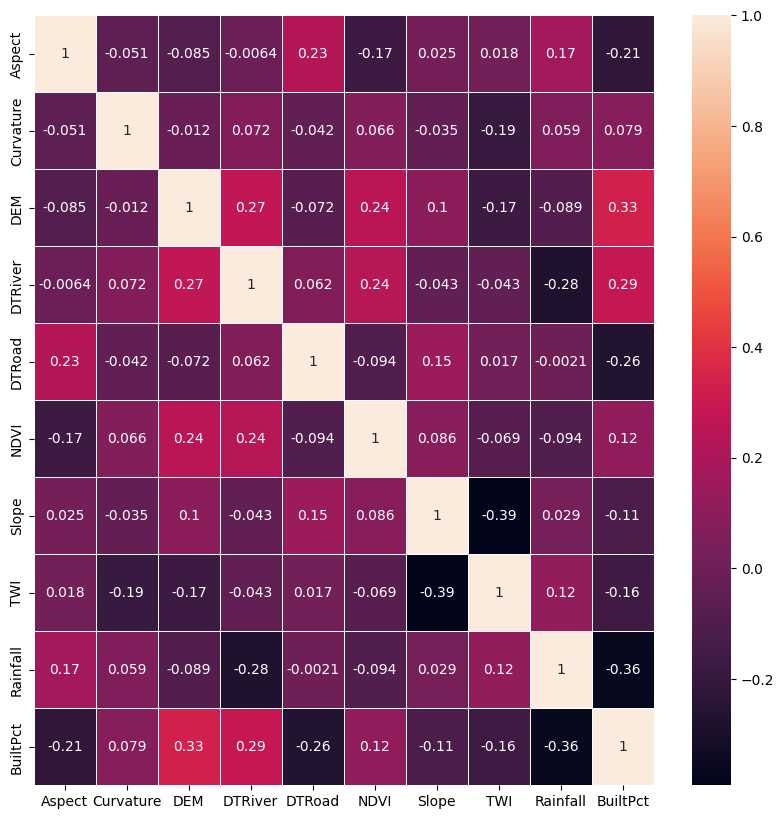

In [12]:
# This cell creates a correlation heatmap for flooded locations.
# Comparing this with the previous heatmap helps reveal differences in flood drivers.

# Correlation between the input features for flooded locations is shown.

corrMatrix = ones_labels.corr()
fig, ax = plt.subplots(figsize=(10,10))         # Sample figsize in inches
#sns.heatmap(df.iloc[:, 1:6:], annot=True, linewidths=.5, ax=ax)
sns.heatmap(corrMatrix, annot=True, linewidths=.5, ax=ax)

In [13]:
# This cell defines the target variable Y.
# Y contains the label values: 0 = not flooded, 1 = flooded.

# Define the dependent variable that needs to be predicted ('Label', whether the location is flooded or not).
Y = df["Label"].values
print(f"Dependent variable (Y) shape: {Y.shape}")
print(Y)

Dependent variable (Y) shape: (302,)
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [14]:
# This cell defines the input features X. We will use these features to predict the target variable Y (whether a location is flooded or not).
# These are the flood-conditioning variables used to predict the class label.
# We remove the target and geometry columns because they are not input features.

X = df.drop(labels = ["Label",'geometry','x','y'], axis=1) 
features_list = list(X.columns)  # List features so we can rank them later
print(f"The list of features is: {features_list}")
print(f"Independent variables (X) shape: {X.shape}")
print(X)

The list of features is: ['Aspect', 'Curvature', 'DEM', 'DTRiver', 'DTRoad', 'NDVI', 'Slope', 'TWI', 'Rainfall', 'BuiltPct']
Independent variables (X) shape: (302, 10)
       Aspect     Curvature     DEM   DTRiver    DTRoad      NDVI     Slope  \
0    103.5480  9.556440e+09  1576.0  240.1400  379.6950  0.595304  35.39290   
1      1.7357  2.730410e+09  1372.0    0.0000   42.4512  0.397266   7.82190   
2    315.0000 -5.460830e+09  1378.0   42.4512  361.4590  0.250189   1.34835   
3    232.1250 -2.730410e+09  1393.0   84.9023  123.7650  0.397909   2.71616   
4     80.5377  0.000000e+00  1480.0   30.0175   90.0525  0.178881   5.78086   
..        ...           ...     ...       ...       ...       ...       ...   
297  180.0000  1.365210e+09  1462.0  702.6920    0.0000  0.403091   5.23025   
298  143.9730  1.365210e+09  1433.0  421.3160    0.0000  0.275327   6.45774   
299  140.9470  2.730410e+09  1504.0  618.8270  120.0700  0.600530  15.85340   
300  153.4350  0.000000e+00  1516.0  752.8

In [15]:
# This cell splits the data into training and test sets.
# The test set is kept unseen so we can evaluate the model fairly.

# Split data into train, validation and test to verify accuracy after fitting the model 
# Firstly split the data into train_validation and test datasets then split the train_validation dataset into train and validation datasets.
# The training dataset is used to train the model, the validation dataset is used for hyperparamter tuning and the testing dataset is used to test the model. 
# It is recommended to test the model with data that the model hasn't seen in the training process.
# Currently splitting the data into 80% training and 20% testing datasets. The training dataset will be further split into training and validation datasets in the next cell.

X_train_val, X_test, y_train_val, y_test = train_test_split(X, Y, test_size=0.20,shuffle=True, random_state=42)

In [16]:
# This cell splits the remaining training data into training and validation sets.
# Validation helps choose model settings before final testing.
# Here we are splitting the training dataset into training and validation datasets. The training dataset will be used to train the model and the validation dataset will be used to tune the hyperparameters of the model. The validation dataset is used to evaluate the model performance during the training process.
# The training dataset is 64% of the total dataset and the validation dataset is 16% of the total dataset. The test dataset is 20% of the total dataset. 

X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.20,shuffle=True, random_state=42)

In [17]:
# This cell defines the candidate settings for the Random Forest model.
# We test different values to find a combination that performs well.

# Define a parameter grid for Random Forest.
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [18]:
# This cell creates the Random Forest classifier object (an instance of the machine learning model we are using).

# Instantiate the Random Forest classifier.
model = RandomForestClassifier(random_state = 42)

In [19]:
# This cell runs a randomised search for the best model parameters.
# Cross-validation checks which settings generalise best. Generalisation refers to how well the model performs on unseen data, which is crucial for real-world applications.

# Perform RandomizedSearchCV with cross-validation.
random_search = RandomizedSearchCV(estimator=model, param_distributions=param_grid,
                                   n_iter=10, scoring='f1', cv=5, verbose=1, random_state=42)
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   param_distributions={'max_depth': [None, 10, 20],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 200]},
                   random_state=42, scoring='f1', verbose=1)

In [20]:
# This cell trains the Random Forest model on the training data.

# Train the model on training data.
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [21]:
# This cell prints the best hyperparameters selected by the search.

# Get the best hyperparameters found.
best_model = random_search.best_estimator_
print("Best hyperparameters found: ", random_search.best_params_)

Best hyperparameters found:  {'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': None}


In [22]:
# This cell makes flood predictions on the test dataset.

# Make predictions on the test set.
prediction = best_model.predict(X_test)

In [23]:
# This cell displays the predictions generated by the model.

# Prediction are 1 (Flooded) and 0 (Not flooded).
prediction 

array([0., 0., 1., 0., 1., 1., 1., 1., 0., 1., 1., 1., 1., 0., 1., 1., 1.,
       0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 1., 0., 1., 0., 0., 0., 1.,
       1., 0., 0., 1., 1., 1., 1., 1., 0., 1., 1., 0., 0., 1., 0., 0., 0.,
       0., 0., 1., 0., 0., 0., 1., 0., 0., 0.])

AUC: 0.993548387096774


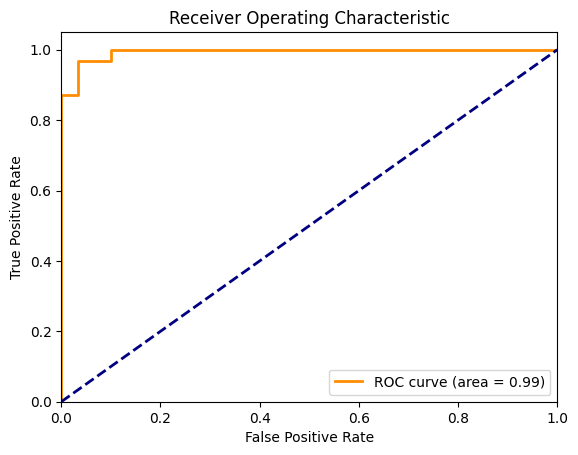

In [24]:
# This cell plots the ROC curve and computes the AUC.
# ROC shows how well the model separates flooded and non-flooded cases.

# Draw the Receiver Operating Characteristics and estimate the Area under the curve (AUC).
# Assuming model is your classifier and X_test, y_test are your test data.
y_score = best_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.15f}")

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [25]:
# This cell asks the model for the probability of flooding for each test sample.

# In order to map the flood susceptibility, we need to predict the flood susceptibility (probability between 0 and 1)
prediction_prob=best_model.predict_proba(X_test)

In [26]:
# This cell shows the probability output for every test case.
# Each row contains two values: probability of not flooded and probability of flooded.

# The probability of being not flooded and flooded for every location (Their summation equals 1).
prediction_prob

array([[0.81385714, 0.18614286],
       [0.98      , 0.02      ],
       [0.        , 1.        ],
       [0.78083333, 0.21916667],
       [0.02      , 0.98      ],
       [0.23133333, 0.76866667],
       [0.10666667, 0.89333333],
       [0.40433333, 0.59566667],
       [0.983     , 0.017     ],
       [0.032     , 0.968     ],
       [0.17533333, 0.82466667],
       [0.        , 1.        ],
       [0.025     , 0.975     ],
       [0.77628571, 0.22371429],
       [0.045     , 0.955     ],
       [0.02      , 0.98      ],
       [0.33      , 0.67      ],
       [0.996     , 0.004     ],
       [0.52833333, 0.47166667],
       [0.99      , 0.01      ],
       [0.558     , 0.442     ],
       [0.71533333, 0.28466667],
       [0.965     , 0.035     ],
       [0.        , 1.        ],
       [0.10783333, 0.89216667],
       [1.        , 0.        ],
       [0.94133333, 0.05866667],
       [0.09266667, 0.90733333],
       [0.87733333, 0.12266667],
       [0.19819048, 0.80180952],
       [0.

In [27]:
# This cell extracts only the probability of the flooded class.
# This value is usually used for flood susceptibility mapping.

ls=prediction_prob[:,1]
ls.shape
print(ls) # Here I'm just printing the actual values.

[0.18614286 0.02       1.         0.21916667 0.98       0.76866667
 0.89333333 0.59566667 0.017      0.968      0.82466667 1.
 0.975      0.22371429 0.955      0.98       0.67       0.004
 0.47166667 0.01       0.442      0.28466667 0.035      1.
 0.89216667 0.         0.05866667 0.90733333 0.12266667 0.80180952
 0.48333333 0.32933333 0.10533333 0.948      1.         0.14
 0.36366667 0.99714286 0.76690476 0.63183333 1.         0.85166667
 0.48333333 0.83380952 0.948      0.02333333 0.10533333 0.60590476
 0.05366667 0.17080952 0.15466667 0.05633333 0.47657143 0.9
 0.03566667 0.08466667 0.06       0.99333333 0.13666667 0.096
 0.06733333]


In [28]:
# This cell prints a classification report.
# It summarises precision, recall, and F1-score for each class. These are additional performance indices that are useful for evaluating classification models. They are important because they provide a more complete picture of model performance, especially in imbalanced datasets.

# As flood susceptibility is classification problem (flooded or not flooded), we can calculate some additional performance indices.
target_names=["Not Flooded","Flooded"]
print(classification_report(y_test, prediction, target_names=target_names))

              precision    recall  f1-score   support

 Not Flooded       0.88      0.97      0.92        30
     Flooded       0.96      0.87      0.92        31

    accuracy                           0.92        61
   macro avg       0.92      0.92      0.92        61
weighted avg       0.92      0.92      0.92        61



In [29]:
# This cell calculates Cohen's Kappa score.
# Kappa measures agreement while correcting for agreement that could happen by chance.


# Cohen's Kappa is a statistic that measures inter-rater agreement for categorical items. It is generally thought to be a more robust measure than simple percent agreement calculation, as κ takes into account the agreement occurring by chance.
print(cohen_kappa_score(y_test, prediction))

0.836285560923242


In [30]:
# This cell computes the confusion matrix.
# The matrix shows how many actual flooded/non-flooded points were correctly or wrongly predicted.

cm = confusion_matrix(y_test, prediction)
labels = ["Not Flooded (0)", "Flooded (1)"]

cm_df = pd.DataFrame(
    cm,
    index=["Actual: Not Flooded", "Actual: Flooded"],
    columns=["Predicted: Not Flooded", "Predicted: Flooded"]
)

print(cm_df)

                     Predicted: Not Flooded  Predicted: Flooded
Actual: Not Flooded                      29                   1
Actual: Flooded                           4                  27


In [31]:
# This cell calculates feature importance.
# The model tells us which variables contribute most to predicting flooding. Higher the value, more important the feature is in predicting flooding. This is useful for understanding which factors are most influential in flood susceptibility.

feature_imp = pd.Series(best_model.feature_importances_, index=features_list).sort_values(ascending=False)
print(f"Feature importances:\n{feature_imp}")

Feature importances:
DTRiver      0.340954
DTRoad       0.143547
TWI          0.142275
Slope        0.135097
NDVI         0.057198
Rainfall     0.046674
DEM          0.046300
Curvature    0.030771
BuiltPct     0.028879
Aspect       0.028305
dtype: float64


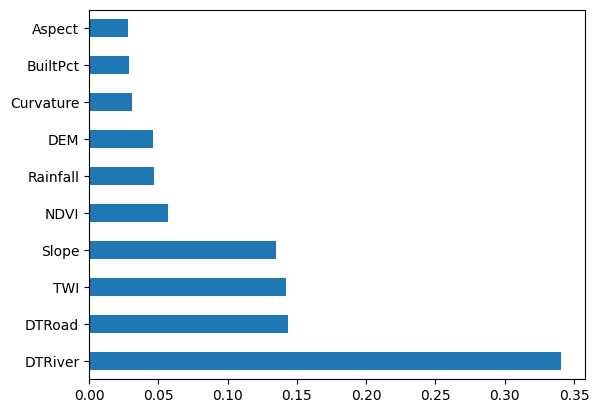

In [32]:
# This cell saves the feature importance chart as an image file.

# Assuming 'feature_imp' is a DataFrame or Series containing feature importances.
ax = feature_imp.plot.barh()
fig = ax.get_figure()
fig.savefig("feature_imp.jpg")

In [33]:
# This cell imports SHAP for model explanation.
# SHAP helps explain which features drove the model's prediction. It stands for SHapley Additive exPlanations and is based on game theory. It provides insight into how each feature contributes to the model's output.

shap.initjs()

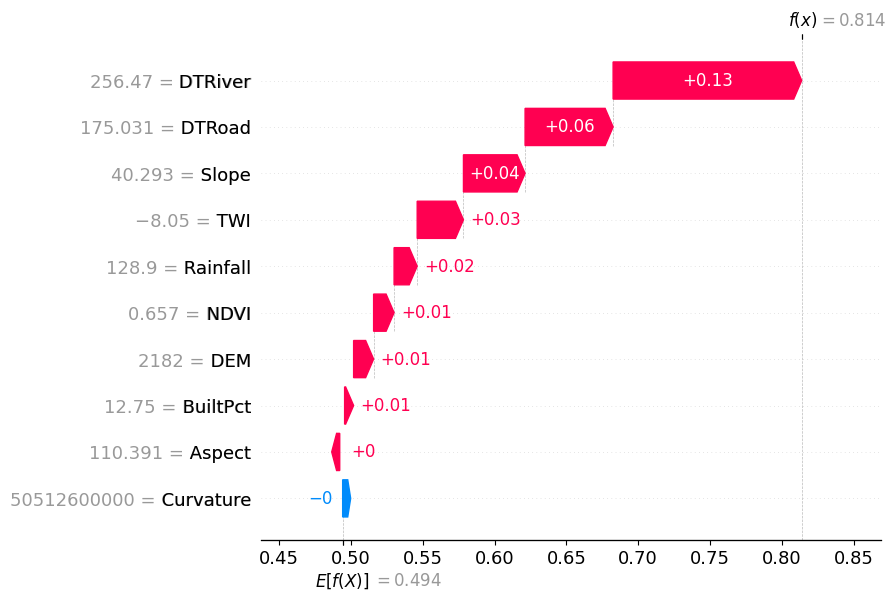

In [34]:
# This cell creates the SHAP explainer for the trained model.
# It also creates a waterfall plot for the first prediction.
# It shows which features pushed the prediction toward flooded or not flooded.

# (same syntax works for LightGBM, CatBoost, scikit-learn, transformers, Spark, etc.)
explainer = shap.Explainer(best_model)
shap_values = explainer(X_test)

# visualise the first prediction's explanation
shap.plots.waterfall(shap_values[0, : , 0])

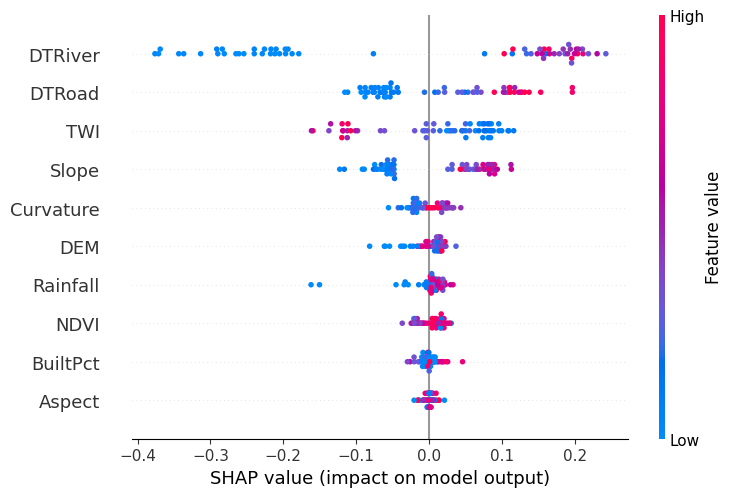

In [35]:
# This cell creates a beeswarm plot for all feature effects.
# It shows the overall influence of each feature across the dataset.
shap.plots.beeswarm(shap_values[:,:,0])

In [36]:
# Visualise the first prediction's explanation with a force plot. This is a more interactive way to see how each feature contributes to the prediction for a specific instance. The force plot shows the base value (average model output) and how each feature pushes the prediction higher or lower.
shap.plots.force(shap_values[:,:,0])

#### Applying the model to the Nyabarongo Catchment

In [37]:
# Step 1: Load the study-area data
# This file contains the wider catchment area for the flood susceptibility model.
# We are reading the shapefile that represents the whole Nyabarongo study area.
# This dataset is larger than the sample points and will be used to generate a flood-risk map across the region.

# Step 2: Save the study-area data in a Python-friendly format
# This keeps the spatial data in the same structure used by GeoPandas.
# This step prepares the data so we can work with it easily in Python before prediction.
gdf = gpd.read_file(r"C:\Users\Sandhra George\FSM-data\QGIS_Data\StudyArea\Nyabarongo_ML_Grid_Final.shp")

In [38]:
# Step 3: Save the data to a .pkl file
# A .pkl file stores the dataset on disk so it can be loaded again later.
# This saves time because we do not need to read the shapefile again every time.
with open('converted_data.pkl', 'wb') as f:
    pickle.dump(gdf, f)

In [39]:
# This cell displays the first rows of the study-area data.
gdf.head()

,fid,OBJECTID,Aspect,CN,Curvature,DEM,DTRiver,DTRoad,NDVI,Slope,...,TEST_min,TEST_max,NDVI_Chang,BLT_count,BLT_mean,BuiltPct,WET_count,WET_mean,WetnessDec,geometry
0,1.0,1.0,40.7155,80.0,1.092170e+10,2080.0,216.459,0.0000,0.571529,16.80050,...,-0.319502,0.176009,-0.055045,400.0,0.0000,0.00,100.0,0.0,0.0,"POLYGON ((442917.073 4714211.429, 442917.073 4..."
1,2.0,2.0,15.4885,80.0,-1.774770e+10,2060.0,295.638,30.0175,0.652466,19.71610,...,-0.340660,0.172467,-0.065072,400.0,0.0775,7.75,100.0,0.0,0.0,"POLYGON ((443117.073 4714211.429, 443117.073 4..."
2,3.0,3.0,334.7990,74.0,-6.826030e+09,2069.0,495.061,30.0175,0.666192,17.36470,...,-0.337399,0.331793,0.009440,400.0,0.1575,15.75,100.0,0.0,0.0,"POLYGON ((443317.073 4714211.429, 443317.073 4..."
3,4.0,4.0,318.5040,74.0,5.460830e+09,2124.0,484.018,0.0000,0.549979,30.01720,...,-0.392942,0.230491,-0.095587,400.0,0.2925,29.25,100.0,0.0,0.0,"POLYGON ((443517.073 4714211.429, 443517.073 4..."
4,5.0,5.0,280.0080,74.0,4.095620e+09,2168.0,503.185,67.1212,0.613816,4.10839,...,-0.387389,0.179575,-0.087775,400.0,0.6300,63.00,100.0,0.0,0.0,"POLYGON ((443717.073 4714211.429, 443717.073 4..."


In [40]:
# This cell removes the geometry column before prediction.
# The model only needs the feature values, not the spatial geometry itself.
X_hotspot0= gdf.drop(labels = ["geometry"], axis=1) 
X_hotspot0.head()

,fid,OBJECTID,Aspect,CN,Curvature,DEM,DTRiver,DTRoad,NDVI,Slope,...,TEST_mean,TEST_min,TEST_max,NDVI_Chang,BLT_count,BLT_mean,BuiltPct,WET_count,WET_mean,WetnessDec
0,1.0,1.0,40.7155,80.0,1.092170e+10,2080.0,216.459,0.0000,0.571529,16.80050,...,-0.055045,-0.319502,0.176009,-0.055045,400.0,0.0000,0.00,100.0,0.0,0.0
1,2.0,2.0,15.4885,80.0,-1.774770e+10,2060.0,295.638,30.0175,0.652466,19.71610,...,-0.065072,-0.340660,0.172467,-0.065072,400.0,0.0775,7.75,100.0,0.0,0.0
2,3.0,3.0,334.7990,74.0,-6.826030e+09,2069.0,495.061,30.0175,0.666192,17.36470,...,0.009440,-0.337399,0.331793,0.009440,400.0,0.1575,15.75,100.0,0.0,0.0
3,4.0,4.0,318.5040,74.0,5.460830e+09,2124.0,484.018,0.0000,0.549979,30.01720,...,-0.095587,-0.392942,0.230491,-0.095587,400.0,0.2925,29.25,100.0,0.0,0.0
4,5.0,5.0,280.0080,74.0,4.095620e+09,2168.0,503.185,67.1212,0.613816,4.10839,...,-0.087775,-0.387389,0.179575,-0.087775,400.0,0.6300,63.00,100.0,0.0,0.0


In [41]:
# This cell keeps only the same feature columns that were used during model training.
# The order of the columns is important because the model expects the same input structure.
# If the data is not in the same order, the model may not interpret the features correctly.
cols = X.columns
cols

Index(['Aspect', 'Curvature', 'DEM', 'DTRiver', 'DTRoad', 'NDVI', 'Slope',
       'TWI', 'Rainfall', 'BuiltPct'],
      dtype='object')

In [42]:
# This cell selects only the feature columns used during model training.
# The order of these columns must match the training data exactly.
# If the order changes, the model may make incorrect predictions.
X_hotspot0 = X_hotspot0[cols]

# Display the first few rows to confirm the data is aligned correctly.
X_hotspot0.head()

,Aspect,Curvature,DEM,DTRiver,DTRoad,NDVI,Slope,TWI,Rainfall,BuiltPct
0,40.7155,1.092170e+10,2080.0,216.459,0.0000,0.571529,16.80050,0.00000,158.3,0.00
1,15.4885,-1.774770e+10,2060.0,295.638,30.0175,0.652466,19.71610,-1.91610,158.3,7.75
2,334.7990,-6.826030e+09,2069.0,495.061,30.0175,0.666192,17.36470,-2.22358,158.3,15.75
3,318.5040,5.460830e+09,2124.0,484.018,0.0000,0.549979,30.01720,-6.27979,158.3,29.25
4,280.0080,4.095620e+09,2168.0,503.185,67.1212,0.613816,4.10839,-5.58122,158.3,63.00


In [43]:
# This cell removes rows with missing values.
# The model cannot process incomplete data reliably.
print(X_hotspot0.isnull().sum())

Aspect        0
Curvature     0
DEM           0
DTRiver       0
DTRoad        0
NDVI          0
Slope         0
TWI           0
Rainfall      0
BuiltPct     61
dtype: int64


In [44]:
# This cell creates a clean version of the study-area data for prediction.
# We remove rows with missing values because the model cannot process incomplete inputs.
# `X_hotspot0` contains the feature values that will be used for prediction.
# `df` is the GeoDataFrame that will later receive the flood susceptibility score.
X_hotspot0 = X_hotspot0.dropna().copy()
df = gdf.dropna().copy()

In [45]:
len(df)

213847

In [46]:
# This cell predicts the flood probability for every location in the study area.
# Higher values mean greater flood susceptibility.

prediction_prob=best_model.predict_proba(X_hotspot0)

In [47]:
# This cell displays the model output probabilities.

prediction_prob

array([[0.50802381, 0.49197619],
       [0.4695    , 0.5305    ],
       [0.48083333, 0.51916667],
       ...,
       [0.87266667, 0.12733333],
       [0.88766667, 0.11233333],
       [0.7295    , 0.2705    ]])

In [48]:
# This cell extracts only the probability of the flooded class.
# This probability will be stored as the final flood susceptibility score.

ls_hotspot0=prediction_prob[:,1]
ls_hotspot0

array([0.49197619, 0.5305    , 0.51916667, ..., 0.12733333, 0.11233333,
       0.2705    ])

In [49]:
# This cell adds the flood susceptibility score to the study-area dataset.
# The new column is named FSM and stores the risk score.

df['FSM']=ls_hotspot0
df.head()

,fid,OBJECTID,Aspect,CN,Curvature,DEM,DTRiver,DTRoad,NDVI,Slope,...,TEST_max,NDVI_Chang,BLT_count,BLT_mean,BuiltPct,WET_count,WET_mean,WetnessDec,geometry,FSM
0,1.0,1.0,40.7155,80.0,1.092170e+10,2080.0,216.459,0.0000,0.571529,16.80050,...,0.176009,-0.055045,400.0,0.0000,0.00,100.0,0.0,0.0,"POLYGON ((442917.073 4714211.429, 442917.073 4...",0.491976
1,2.0,2.0,15.4885,80.0,-1.774770e+10,2060.0,295.638,30.0175,0.652466,19.71610,...,0.172467,-0.065072,400.0,0.0775,7.75,100.0,0.0,0.0,"POLYGON ((443117.073 4714211.429, 443117.073 4...",0.530500
2,3.0,3.0,334.7990,74.0,-6.826030e+09,2069.0,495.061,30.0175,0.666192,17.36470,...,0.331793,0.009440,400.0,0.1575,15.75,100.0,0.0,0.0,"POLYGON ((443317.073 4714211.429, 443317.073 4...",0.519167
3,4.0,4.0,318.5040,74.0,5.460830e+09,2124.0,484.018,0.0000,0.549979,30.01720,...,0.230491,-0.095587,400.0,0.2925,29.25,100.0,0.0,0.0,"POLYGON ((443517.073 4714211.429, 443517.073 4...",0.207000
4,5.0,5.0,280.0080,74.0,4.095620e+09,2168.0,503.185,67.1212,0.613816,4.10839,...,0.179575,-0.087775,400.0,0.6300,63.00,100.0,0.0,0.0,"POLYGON ((443717.073 4714211.429, 443717.073 4...",0.345333


In [50]:
try:
    from geocube.api.core import make_geocube
    print("make_geocube import OK")
except Exception:
    traceback.print_exc()

make_geocube import OK


In [51]:
# This cell creates a raster grid from the study-area features and flood susceptibility values.
# Raster grids are useful for generating flood risk maps.

geo_grid = make_geocube(
    vector_data=df,
    measurements=['FSM'],
    resolution=(-20, 20) # I have changed the resolution to (-50, 50) because the original resolution of (-20, 20) was too fine and caused memory issues. The new resolution is coarser but should still provide useful spatial detail. Can change it back when required.
)

In [52]:
# This cell plots the flood susceptibility raster.
# This gives a visual map of flood risk across the study area.

geo_grid.FSM.plot()

MemoryError: Unable to allocate 1.55 GiB for an array with shape (7041, 7381, 4) and data type float64

<Figure size 640x480 with 2 Axes>

In [53]:
# This cell saves the raster as a GeoTIFF file.
# The output can be reused in GIS software or reports.

geo_grid.FSM.rio.to_raster("FSM.tif")